
##  Does the release month of a movie significantly affect its box office revenue?

---
![Cover Image](images/movie_rel_mon2.jpg)

## Dataset Overview

The dataset used is `tn.movie_budgets.csv.gz`, located in the `zippedData` folder. It contains information about over 5,700 movies, with the following columns:

- `id`: Unique identifier for each movie  
- `release_date`: The date the movie was released  
- `movie`: Title of the movie  
- `production_budget`: Budget allocated for movie production (as a string with `$`)  
- `domestic_gross`: Revenue generated domestically (as a string with `$`)  
- `worldwide_gross`: Total worldwide revenue (as a string with `$`)  

---


In [1]:
#look at the files in the current directory
!ls

README.md
images
movie_market_analysis.ipynb
release_mon_analysis.ipynb
zippedData


In [2]:
#look at the files in zippeData 
!ls zippedData/

bom.movie_gross.csv.gz
im.db.zip
rt.movie_info.tsv.gz
rt.reviews.tsv.gz
tmdb.movies.csv.gz
tn.movie_budgets.csv.gz


In [3]:
#import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)

## Data Cleaning and Preprocessing

- Inspected the dataset using `.info()` and `.describe()` to understand structure and identify data types.  
- Converted the `production_budget`, `domestic_gross`, and `worldwide_gross` columns from strings to floats by removing `$` and `,`.  
- Parsed the `release_date` column to datetime format.  
- Created two additional columns:  
  - `month`: Extracted release month from `release_date`  
  - `year`: Extracted release year from `release_date`  

---

In [4]:
budgets_df = pd.read_csv("zippedData/tn.movie_budgets.csv.gz")
budgets_df.head()


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [5]:
budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


In [6]:
budgets_df.describe()

,id
count,5782.000000
mean,50.372363
std,28.821076
min,1.000000
25%,25.000000
50%,50.000000
75%,75.000000
max,100.000000


In [7]:
cols_to_clean = ['production_budget', 'domestic_gross', 'worldwide_gross']

for col in cols_to_clean:
    budgets_df[col] = budgets_df[col].replace('[\$,]', '', regex=True).astype(float)

budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5782 non-null   int64  
 1   release_date       5782 non-null   object 
 2   movie              5782 non-null   object 
 3   production_budget  5782 non-null   float64
 4   domestic_gross     5782 non-null   float64
 5   worldwide_gross    5782 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 271.2+ KB


In [8]:
budgets_df['release_date'] = pd.to_datetime(budgets_df['release_date'], errors='coerce')
budgets_df['release_year'] = budgets_df['release_date'].dt.year
budgets_df['release_month'] = budgets_df['release_date'].dt.month
budgets_df.head(20)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,release_year,release_month
0,1,2009-12-18,Avatar,425000000.0,760507625.0,2.776345e+09,2009,12
1,2,2011-05-20,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,2011,5
2,3,2019-06-07,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,2019,6
3,4,2015-05-01,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,2015,5
4,5,2017-12-15,Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09,2017,12
5,6,2015-12-18,Star Wars Ep. VII: The Force Awakens,306000000.0,936662225.0,2.053311e+09,2015,12
6,7,2018-04-27,Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,2018,4
7,8,2007-05-24,Pirates of the Caribbean: At Worldâs End,300000000.0,309420425.0,9.634204e+08,2007,5
8,9,2017-11-17,Justice League,300000000.0,229024295.0,6.559452e+08,2017,11
9,10,2015-11-06,Spectre,300000000.0,200074175.0,8.796209e+08,2015,11


In [9]:
budgets_df.describe()

,id,production_budget,domestic_gross,worldwide_gross,release_year,release_month
count,5782.000000,5.782000e+03,5.782000e+03,5.782000e+03,5782.000000,5782.000000
mean,50.372363,3.158776e+07,4.187333e+07,9.148746e+07,2003.967139,7.050675
std,28.821076,4.181208e+07,6.824060e+07,1.747200e+08,12.724386,3.480147
min,1.000000,1.100000e+03,0.000000e+00,0.000000e+00,1915.000000,1.000000
25%,25.000000,5.000000e+06,1.429534e+06,4.125415e+06,2000.000000,4.000000
50%,50.000000,1.700000e+07,1.722594e+07,2.798445e+07,2007.000000,7.000000
75%,75.000000,4.000000e+07,5.234866e+07,9.764584e+07,2012.000000,10.000000
max,100.000000,4.250000e+08,9.366622e+08,2.776345e+09,2020.000000,12.000000


In [10]:
budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5782 non-null   int64         
 1   release_date       5782 non-null   datetime64[ns]
 2   movie              5782 non-null   object        
 3   production_budget  5782 non-null   float64       
 4   domestic_gross     5782 non-null   float64       
 5   worldwide_gross    5782 non-null   float64       
 6   release_year       5782 non-null   int64         
 7   release_month      5782 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(1)
memory usage: 361.5+ KB


## Initial Visual Exploration

To understand the distribution and relationships in the data:

- Plotted histograms for `production_budget` and `worldwide_gross` to observe skewness and outliers.  
- Created a scatter plot to explore the relationship between `production_budget` and `worldwide_gross`.  
- Used a line plot to show trends in average worldwide gross revenue over the years.  

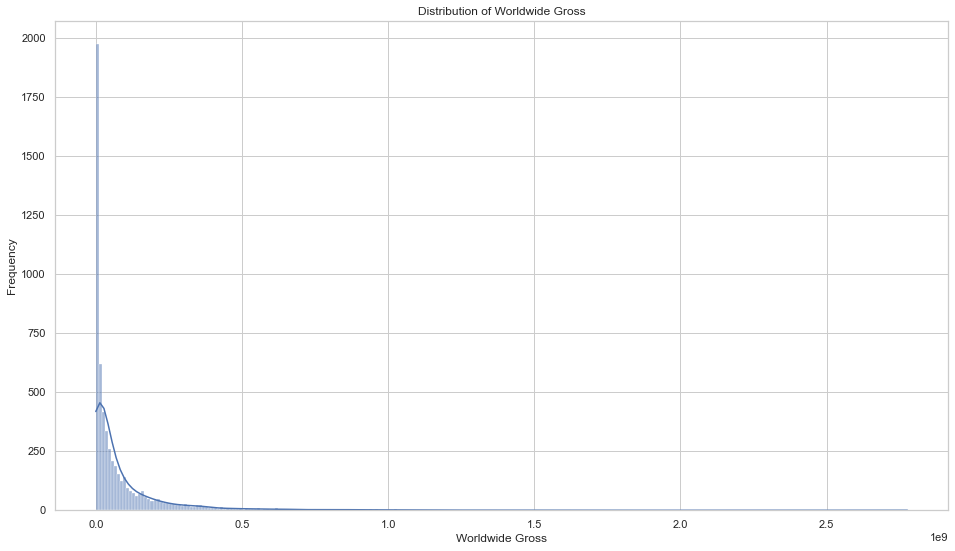

In [11]:
#distribution of Worldwide Gross
sns.histplot(budgets_df['worldwide_gross'], kde=True)
plt.title('Distribution of Worldwide Gross')
plt.xlabel('Worldwide Gross')
plt.ylabel('Frequency')
plt.show()

From this plot, we can observe:

- The distribution of worldwide gross is heavily right-skewed (i.e., most movies make modest revenue, but a few blockbusters make a lot).
- This skewness justifies the idea of normalization or log transformation before running models or tests that assume normality.


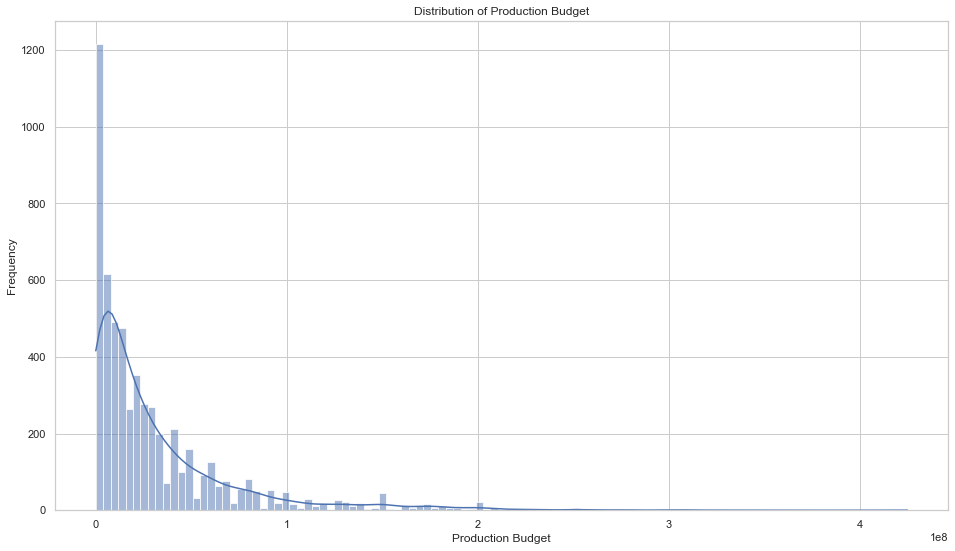

In [12]:

#distribution of Production Budget
sns.histplot(budgets_df['production_budget'], kde=True)
plt.title('Distribution of Production Budget')
plt.xlabel('Production Budget')
plt.ylabel('Frequency')
plt.show()

Similar to `worldwide_gross`, it shows:

- A right-skewed distribution with a few high-budget movies.
- Possible transformation (like log) could stabilize variance in later models.


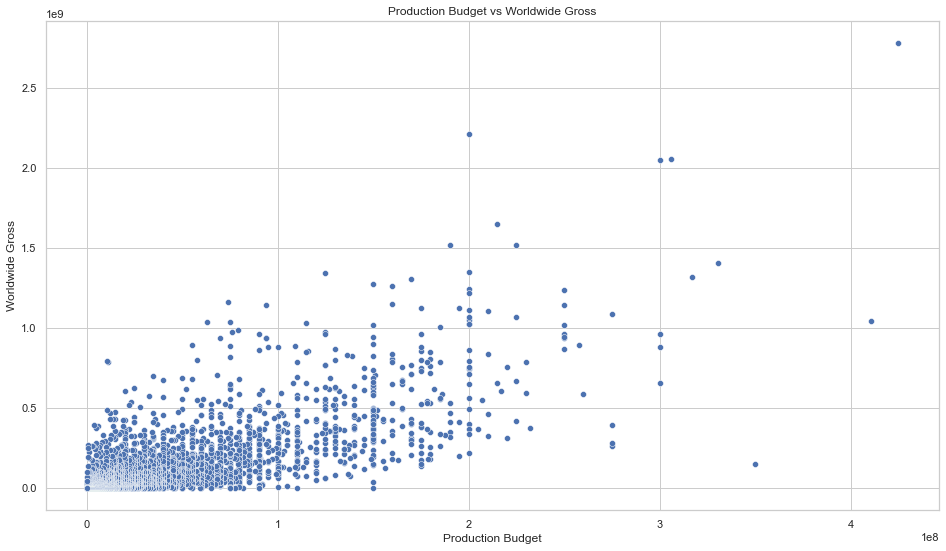

In [13]:
#Scatterplot: Production Budget vs Worldwide Gross
sns.scatterplot(data=budgets_df, x='production_budget', y='worldwide_gross')
plt.title('Production Budget vs Worldwide Gross')
plt.xlabel('Production Budget')
plt.ylabel('Worldwide Gross')
plt.show()


There appears to be a positive relationship—higher production budgets often lead to higher gross revenue.

- However, the spread may increase with budget, suggesting heteroscedasticity (variance not being constant).
- Outliers are visible—very high budget movies that earned much more or much less than expected.


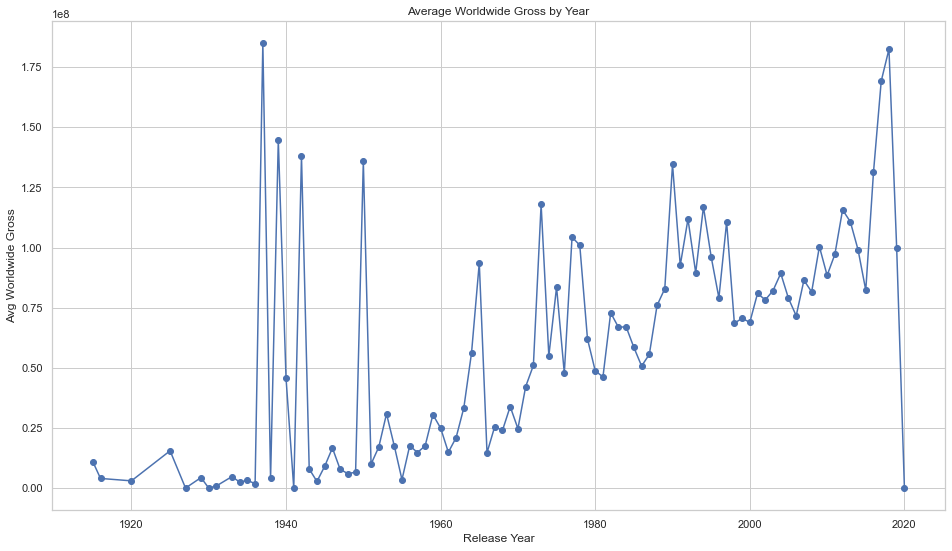

In [14]:
#Line Plot: Average Worldwide Gross by Year
avg_gross_by_year = budgets_df.groupby('release_year')['worldwide_gross'].mean()
avg_gross_by_year.plot(kind='line', marker='o')
plt.title('Average Worldwide Gross by Year')
plt.ylabel('Avg Worldwide Gross')
plt.xlabel('Release Year')
plt.grid(True)
plt.show()

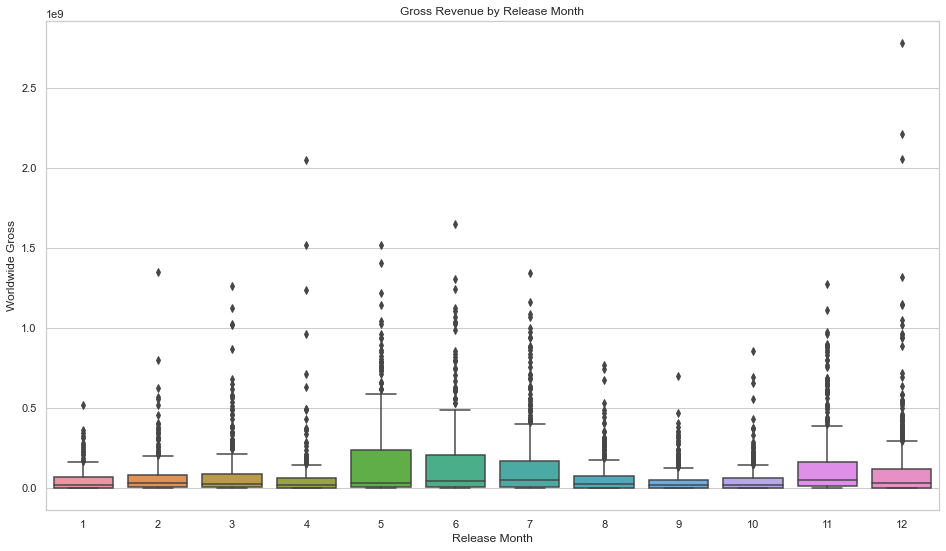

In [15]:
sns.boxplot(data=budgets_df, x='release_month', y='worldwide_gross')
plt.title('Gross Revenue by Release Month')
plt.xlabel('Release Month')
plt.ylabel('Worldwide Gross')
plt.show()

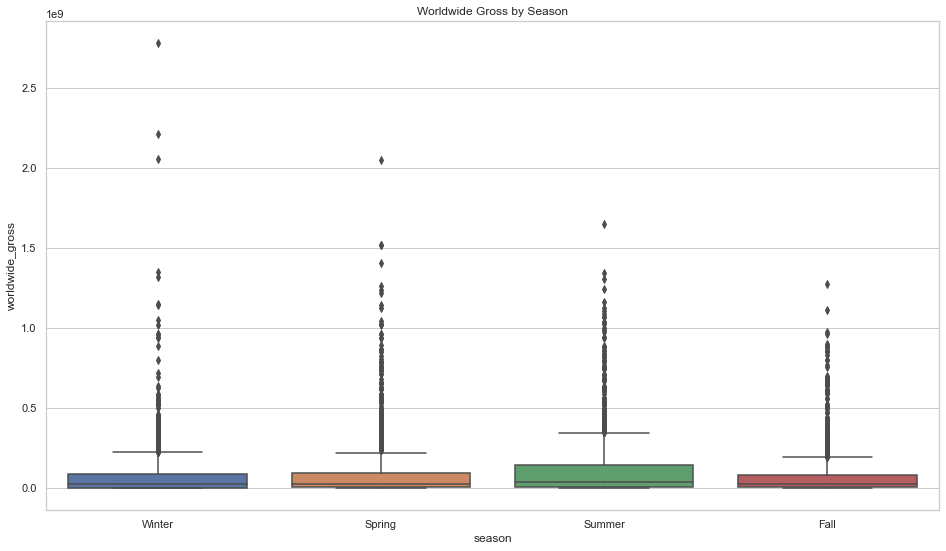

In [16]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

budgets_df['season'] = budgets_df['release_month'].apply(month_to_season)
sns.boxplot(data=budgets_df, x='season', y='worldwide_gross')
plt.title('Worldwide Gross by Season')
plt.show()


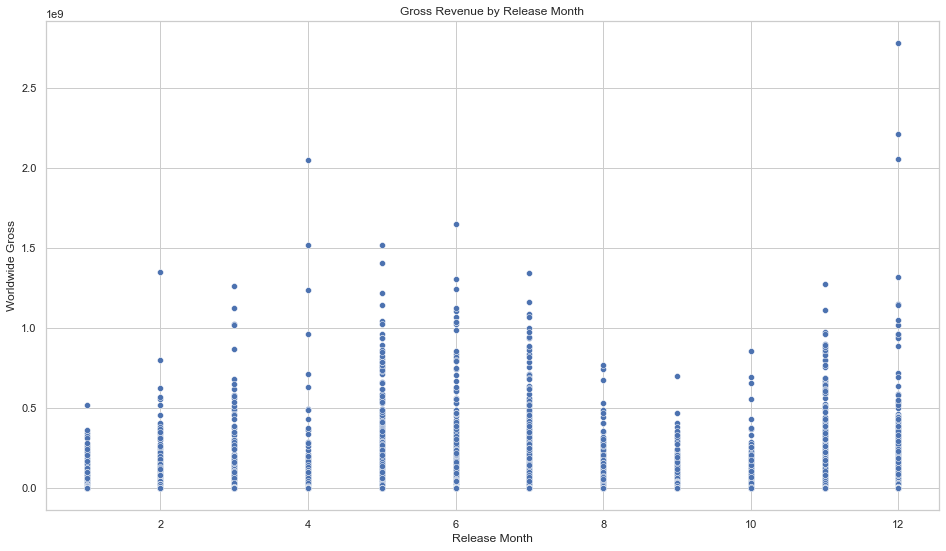

In [17]:
sns.scatterplot(data=budgets_df, x='release_month', y='worldwide_gross')
plt.title('Gross Revenue by Release Month')
plt.xlabel('Release Month')
plt.ylabel('Worldwide Gross')
plt.show()

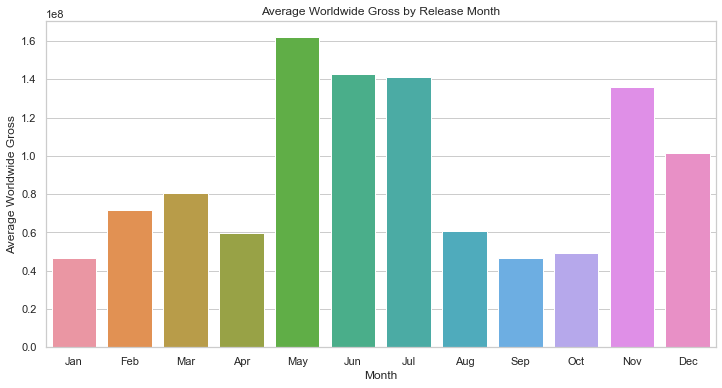

In [18]:
import calendar

#Group by release_month and calculate mean worldwide_gross
monthly_avg_gross = budgets_df.groupby('release_month')['worldwide_gross'].mean()

#Sort months in calendar order
monthly_avg_gross = monthly_avg_gross.reindex(range(1, 13))

#Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_avg_gross.index, y=monthly_avg_gross.values)
plt.xticks(ticks=range(0, 12), labels=[calendar.month_abbr[i+1] for i in range(12)])
plt.title('Average Worldwide Gross by Release Month')
plt.xlabel('Month')
plt.ylabel('Average Worldwide Gross')
plt.show()

## Statistical Analysis

Three statistical approaches were used to assess whether the release month has a significant effect on worldwide box office revenue:

1. One-way ANOVA test  
2. Independent t-test  
3. Linear regression modeling

Due to the right-skewed distributions of `worldwide_gross` and `production_budget`, a log transformation was applied using NumPy's `log1p()` function. This normalization helped satisfy assumptions of normality and homoscedasticity required for parametric tests.

---

In [19]:
budgets_df['log_worldwide_gross'] = np.log1p(budgets_df['worldwide_gross'])
budgets_df['log_production_budget'] = np.log1p(budgets_df['production_budget'])


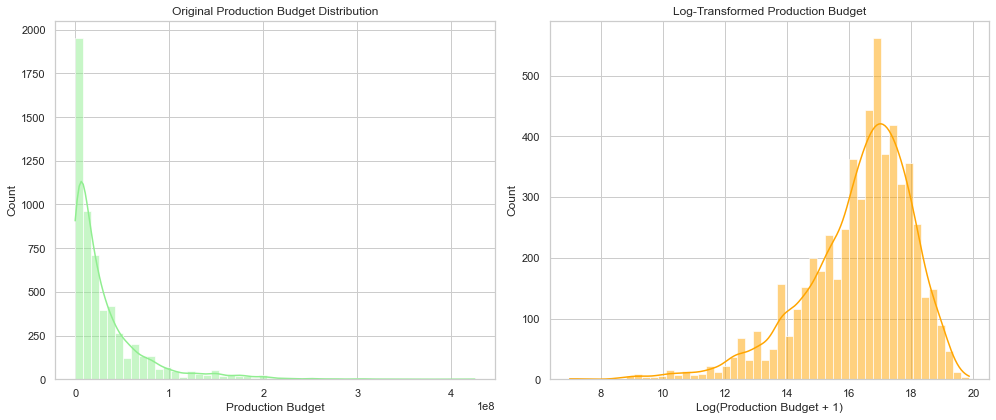

In [20]:
plt.figure(figsize=(14, 6))

# Original production budget distribution
plt.subplot(1, 2, 1)
sns.histplot(budgets_df['production_budget'], bins=50, kde=True, color='lightgreen')
plt.title('Original Production Budget Distribution')
plt.xlabel('Production Budget')

# Log-transformed production budget
plt.subplot(1, 2, 2)
sns.histplot(budgets_df['log_production_budget'], bins=50, kde=True, color='orange')
plt.title('Log-Transformed Production Budget')
plt.xlabel('Log(Production Budget + 1)')

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Log(Worldwide Gross + 1)')

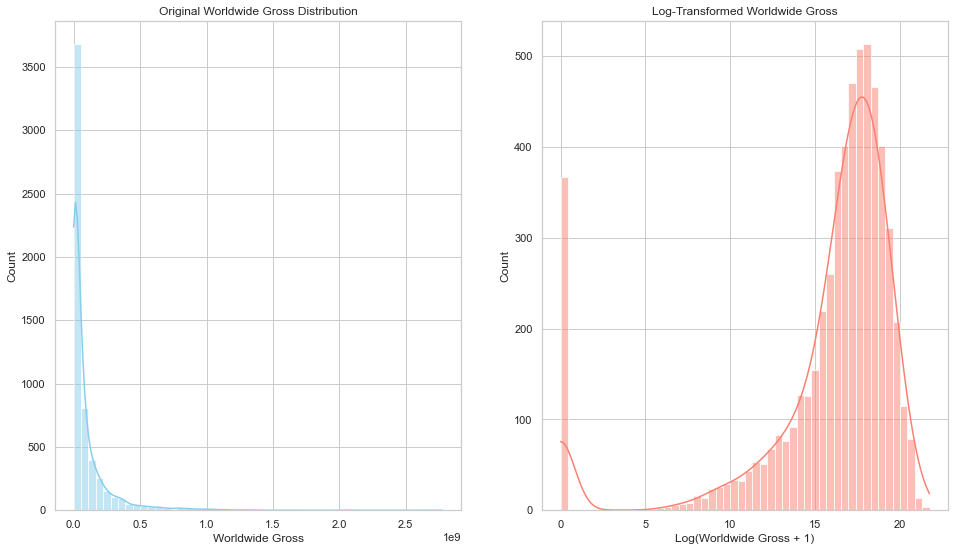

In [21]:
plt.subplot(1, 2, 1)
sns.histplot(budgets_df['worldwide_gross'], bins=50, kde=True, color='skyblue')
plt.title('Original Worldwide Gross Distribution')
plt.xlabel('Worldwide Gross')

# Log-transformed
plt.subplot(1, 2, 2)
sns.histplot(budgets_df['log_worldwide_gross'], bins=50, kde=True, color='salmon')
plt.title('Log-Transformed Worldwide Gross')
plt.xlabel('Log(Worldwide Gross + 1)')

### ANOVA Test

A one-way ANOVA was conducted to determine whether there are statistically significant differences in mean worldwide gross revenue across the twelve release months. This test is appropriate when comparing means across multiple categorical groups.

**Hypotheses:**

- **Null hypothesis (H₀):** The mean worldwide gross revenue is the same across all release months.  
- **Alternative hypothesis (H₁):** At least one release month has a significantly different mean revenue.


In [22]:

anova_df = budgets_df[['release_month', 'log_worldwide_gross']].dropna()

groups = [group['log_worldwide_gross'].values for name, group in anova_df.groupby('release_month')]

# Perform one-way ANOVA test
stat, p = stats.f_oneway(*groups)

print(f'F-statistic: {stat:.3f}')
print(f'p-value: {p:.3f}')


F-statistic: 12.209
p-value: 0.000


**ANOVA Results:**

- **F-statistic:** 12.209  
- **p-value:** 0.000  

The p-value indicates strong evidence against the null hypothesis. Therefore, it can be concluded that average worldwide gross revenue differs significantly between at least two release months.


### Independent T-Test

An independent t-test was conducted to compare the average worldwide gross revenue between movies released in **May** and **November**. These months were chosen due to their strategic importance in the film industry calendar.

**Hypotheses:**

- **Null hypothesis (H₀):** There is no difference in average worldwide gross between May and November releases.  
- **Alternative hypothesis (H₁):** There is a difference in average worldwide gross between May and November releases.


In [23]:
group1 = budgets_df[budgets_df['release_month'] == 5]['log_worldwide_gross']
group2 = budgets_df[budgets_df['release_month'] == 11]['log_worldwide_gross']

t_stat, p_val = stats.ttest_ind(group1, group2, nan_policy='omit')
print(f'T-statistic: {t_stat}, P-value: {p_val}')

T-statistic: -1.0736333572077577, P-value: 0.28327771705496263


**T-Test Results:**

- **T-statistic:** -1.07  
- **P-value:** 0.2833  

The p-value is greater than the commonly used significance level of 0.05, so the null hypothesis cannot be rejected. This indicates that there is **no statistically significant difference** in average worldwide gross revenue between movies released in May and those released in November.

The negative t-statistic suggests that May releases may have slightly higher average revenue than November releases, but the difference is not large enough to be considered statistically significant.

## Linear Regression

![Cover Image](images/linear_reg1.jpg)
---
To explore the relationship between a movie’s production budget and its box office performance, a linear regression model was used.

**Variable Roles:**

- **Independent variable (predictor):** `production_budget`  
- **Dependent variable (response):** `worldwide_gross`


In [24]:
# Calculate correlation
corr, p_value = stats.pearsonr(budgets_df['production_budget'], budgets_df['worldwide_gross'])
print(f"Correlation: {corr:.4f}, P-value: {p_value:.4f}")

Correlation: 0.7483, P-value: 0.0000


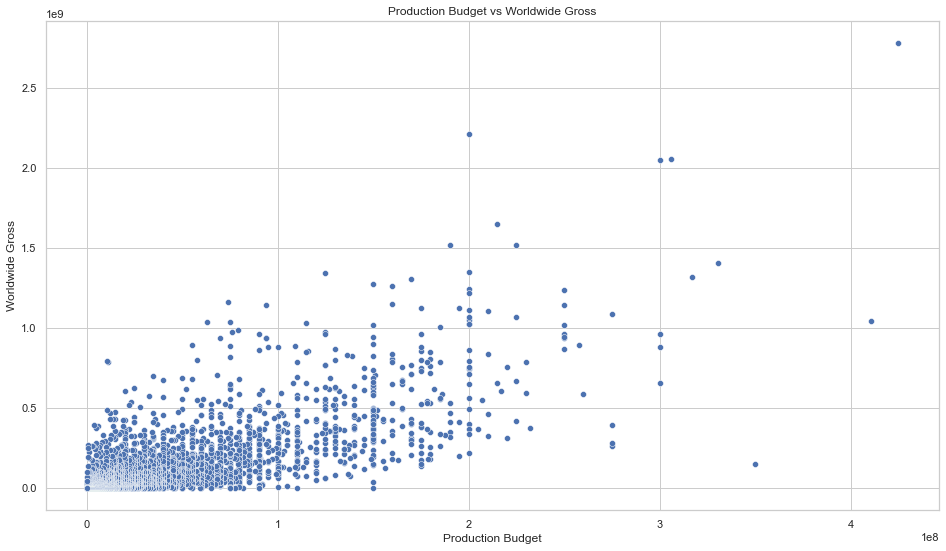

In [25]:
#Scatterplot: Production Budget vs Worldwide Gross
sns.scatterplot(data=budgets_df, x='production_budget', y='worldwide_gross')
plt.title('Production Budget vs Worldwide Gross')
plt.xlabel('Production Budget')
plt.ylabel('Worldwide Gross')
plt.show()

**Justification:**

The objective is to assess whether higher production budgets are associated with higher worldwide gross revenue. Here, `production_budget` serves as the input variable that may influence or predict `worldwide_gross`, making it a suitable independent variable in a regression setup.

A Pearson correlation coefficient of **0.7483** was observed between the two variables, indicating a strong positive linear relationship. This supports the use of linear regression, as there is evidence that increases in production budget are generally associated with increases in gross revenue.

In [26]:

results = sm.OLS(endog=budgets_df['worldwide_gross'],exog=sm.add_constant(budgets_df['production_budget'])).fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:        worldwide_gross   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     7355.
Date:                Thu, 01 May 2025   Prob (F-statistic):               0.00
Time:                        01:06:45   Log-Likelihood:            -1.1557e+05
No. Observations:                5782   AIC:                         2.311e+05
Df Residuals:                    5780   BIC:                         2.311e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -7.286e+06   1.91e+0

###  Model Overview

| Metric              | Value     | Explanation                                                                 |
|---------------------|-----------|-----------------------------------------------------------------------------|
| **R-squared**       | 0.560     | About 56% of the variation in worldwide gross can be explained by production budget. |
| **Adj. R-squared**  | 0.560     | Adjusted R² remains the same here as there's only one independent variable. |
| **F-statistic**     | 7355      | A high F-value suggests the model fits significantly better than a flat line. |
| **Prob (F-statistic)** | 0.000 | Very small p-value indicates the model is statistically significant overall. |

---

### Coefficients Table

| Term                  | Coefficient   | p-value | Interpretation                                                                            |
|-----------------------|---------------|---------|-------------------------------------------------------------------------------------------|
| **Intercept (const)** | -7,286,000    | 0.000   | The baseline value when production budget is zero .  |
| **Production Budget** | 3.13          | 0.000   | For every extra dollar spent, worldwide gross increases by ~$3.13, on average.           |

---

### Regression Equation

$$
\text{Worldwide Gross} = 3.13 \times \text{Production Budget} - 7{,}286{,}000
$$


---

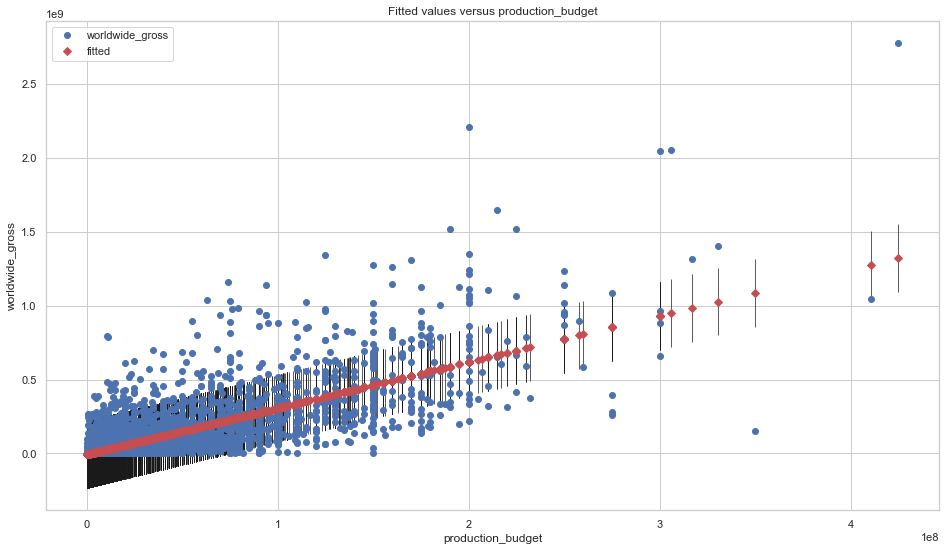

In [27]:
sm.graphics.plot_fit(results, "production_budget")
plt.show()

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


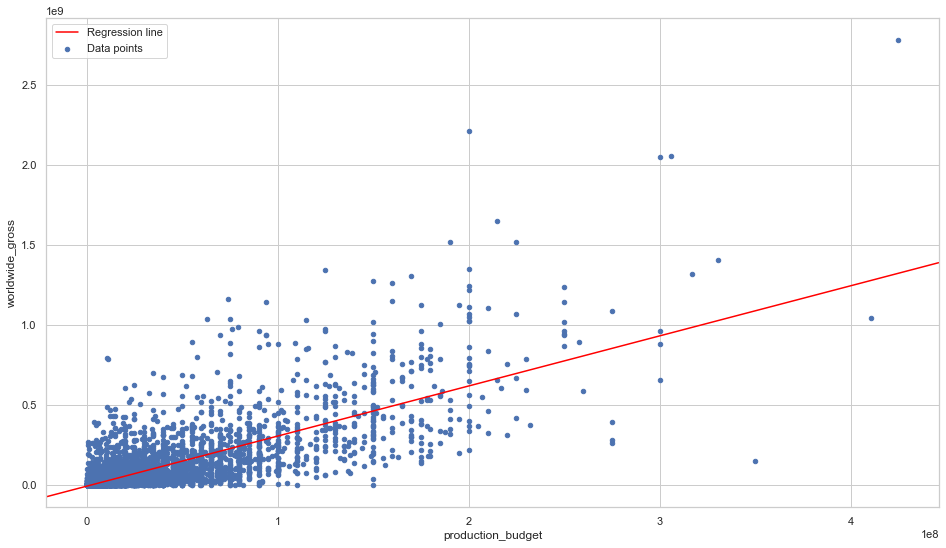

In [28]:
#drawing the regression line
fig, ax = plt.subplots()
budgets_df.plot.scatter(x="production_budget", y="worldwide_gross", label="Data points", ax=ax)
sm.graphics.abline_plot(model_results=results, label="Regression line", ax=ax,color="red")
ax.legend();

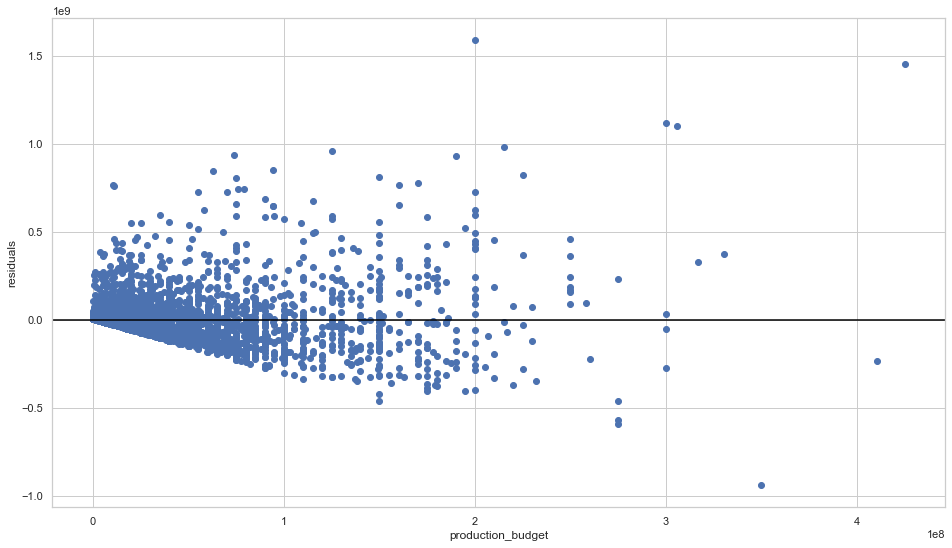

In [29]:
#visualizing residuals 
fig, ax = plt.subplots()

ax.scatter(budgets_df["production_budget"], results.resid)
ax.axhline(y=0, color="black")
ax.set_xlabel("production_budget")
ax.set_ylabel("residuals");

## Log Transformation
In the original dataset, both the **production_budget** and **worldwide_gross** had **highly skewed distributions** with long right tails. This kind of skew is common in financial data due to outliers and a wide range of values.

To address this, we applied a **logarithmic transformation** using `np.log1p()`, which safely handles zero and small values by computing `log(1 + x)`:


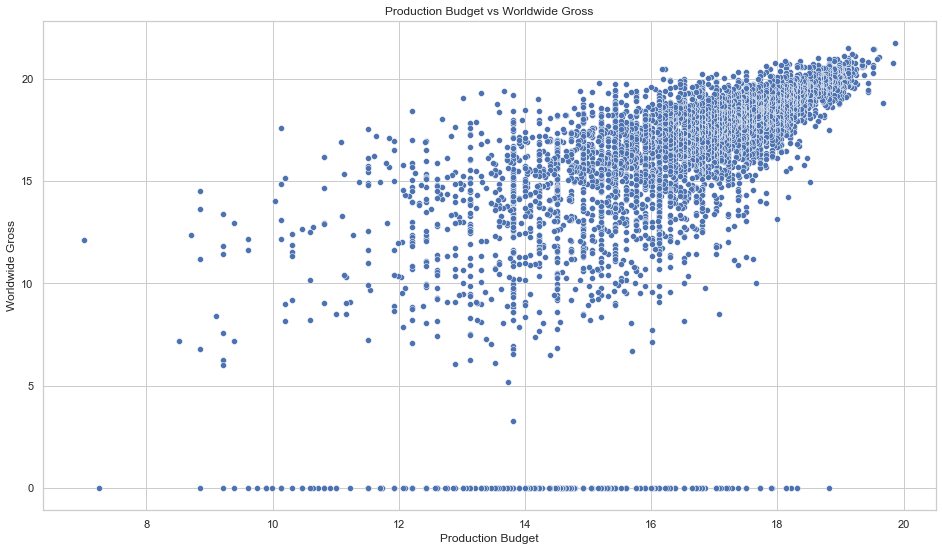

In [30]:
#scatterplot of the log_transformed data
sns.scatterplot(data=budgets_df, x='log_production_budget', y='log_worldwide_gross')
plt.title('Production Budget vs Worldwide Gross')
plt.xlabel('Production Budget')
plt.ylabel('Worldwide Gross')
plt.show()

### Interpretation: Log-Log Scatter Plot (log_production_budget vs log_worldwide_gross)

- Clear positive linear relationship  
  The scatter plot shows an upward trend: as `log_production_budget` increases, `log_worldwide_gross` also tends to increase. This indicates a strong positive correlation between the two variables.

- Log transformation effectiveness  
  The data is more evenly spread compared to the original scale. The transformation supports multiplicative relationships:  
  A 1% increase in budget results in an approximately proportional percentage increase in worldwide gross.

- Zero revenue points  
  A horizontal cluster near y = 0 suggests the presence of movies with zero or near-zero revenue. These might be anomalies or failed releases and could warrant further investigation or removal.

- Modeling implications  
  The transformation improves key assumptions of linear regression:  
  - Improved linearity  
  - More constant variance (homoscedasticity)  
  - Compressed skewness


In [31]:
#modeling a linear regression model for the log-tranformed data
results = sm.OLS(endog=budgets_df['log_worldwide_gross'],exog=sm.add_constant(budgets_df['log_production_budget'])).fit()
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:     log_worldwide_gross   R-squared:                       0.364
Model:                             OLS   Adj. R-squared:                  0.364
Method:                  Least Squares   F-statistic:                     3308.
Date:                 Thu, 01 May 2025   Prob (F-statistic):               0.00
Time:                         01:06:48   Log-Likelihood:                -15917.
No. Observations:                 5782   AIC:                         3.184e+04
Df Residuals:                     5780   BIC:                         3.185e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

---

### Model Performance

- **R-squared = 0.364**: About 36.4% of the variation in log(worldwide gross) is explained by log(production budget). While not extremely high, this is a reasonably strong linear relationship considering the simplicity of the model.
- **F-statistic = 3308, p-value < 0.001**: The model is **statistically significant**, indicating that the relationship is not due to random chance.
- **t-value for slope = 57.514, p < 0.001**: The production budget is a **significant predictor** of worldwide gross in the log scale.

---

### Regression Equation

The fitted model is:

$$
\log(\text{worldwide\_gross}) = 1.6575 \cdot \log(\text{production\_budget}) - 11.3219
$$


Which can be interpreted as:

> A 1% increase in the production budget is associated with an approximate **1.66% increase** in worldwide gross revenue, holding other factors constant.



*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


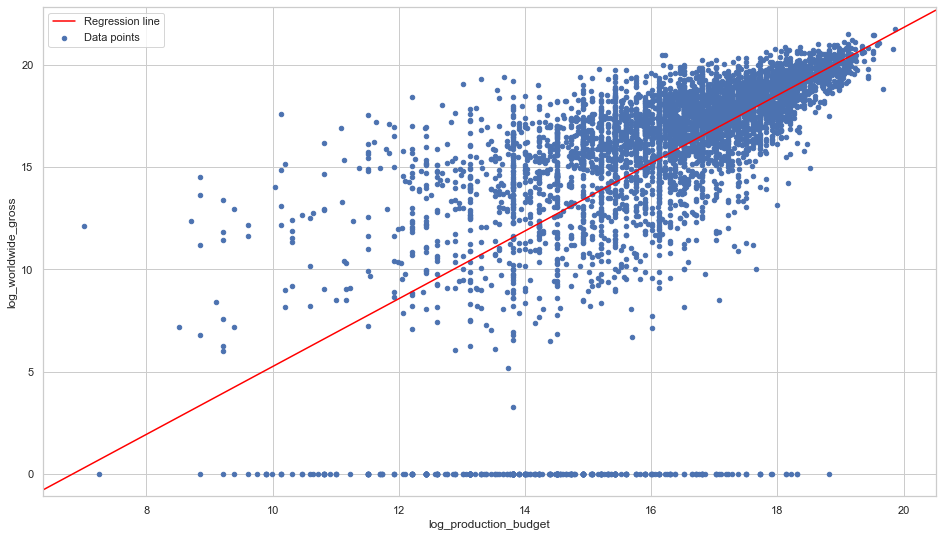

In [32]:
#visualizing the regression line 

fig, ax = plt.subplots()
budgets_df.plot.scatter(x="log_production_budget", y="log_worldwide_gross", label="Data points", ax=ax)
sm.graphics.abline_plot(model_results=results, label="Regression line", ax=ax,color="red")
ax.legend();

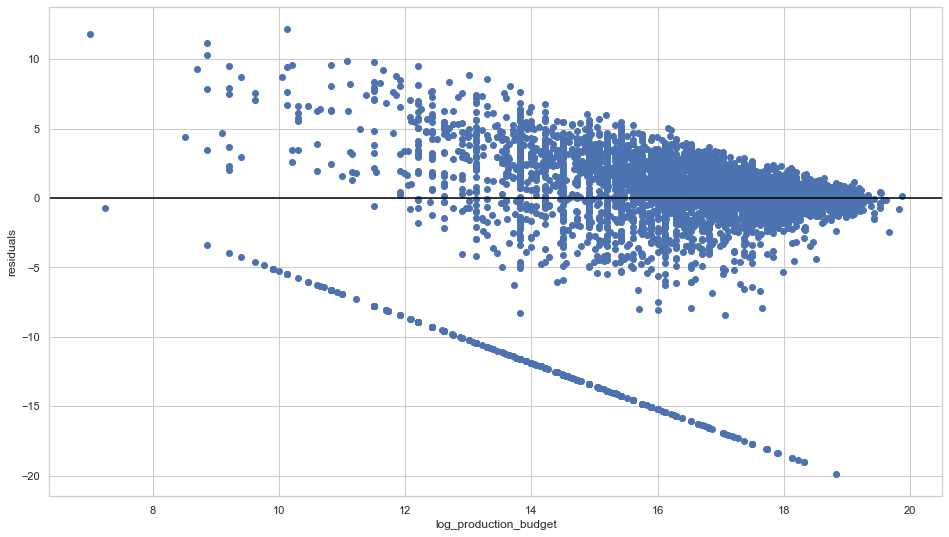

In [33]:
#visualizizing residuals
#visualizing residuals 
fig, ax = plt.subplots()

ax.scatter(budgets_df["log_production_budget"], results.resid)
ax.axhline(y=0, color="black")
ax.set_xlabel("log_production_budget")
ax.set_ylabel("residuals");